# Test State Injection Experiment

Tests the State Injection protocols (corner and middle) for Rotated Surface Code across different distances and injected states (|0⟩ and |+⟩).

In [2]:
import sys
import os
import numpy as np

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from experiments.state_injection import StateInjectionExperiment

## 1. Build circuits (no noise)

Build injection circuits for different Distance, Protocol (corner/middle), and inject_state (Z->|0⟩, X->|+⟩).

In [2]:
results = []
for d in [3, 5]:
    for protocol in ['corner', 'middle']:
        for inject_state in ['Z', 'X']:
            exp = StateInjectionExperiment(
                distance=d,
                rounds=2,
                injection_protocol=protocol,
                inject_state=inject_state,
                noise_params=None,
            )
            circ = exp.build()
            results.append({
                'distance': d,
                'protocol': protocol,
                'inject_state': inject_state,
                'circuit': circ,
                'num_ops': len(circ),
            })
            print(f'd={d} {protocol} {inject_state}: {len(circ)} ops')

Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
d=3 corner Z: 43 ops
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
d=3 corner X: 43 ops
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
d=3 middle Z: 44 ops
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
d=3 middle X: 44 ops
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
d=5 corner Z: 90 ops
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
d=5 corner X: 90 ops
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
d=5 middle Z: 92 ops
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
d=5 middle X: 92 ops


## 2. Verify correctness by sampling (noiseless)

With zero noise, the circuit is deterministic. Sample multiple shots and check that the logical observable matches the injected state.

In [3]:
n_shots = 100
all_pass = True
for r in results:
    circ = r['circuit']
    sampler = circ.compile_detector_sampler()
    dets, obs = sampler.sample(shots=n_shots, separate_observables=True)
    # obs shape: (n_shots, n_observables). For single logical, obs[:, 0]
    # Ideal |0⟩ (Z) and |+⟩ (X) both yield observable 0 in noiseless case
    if not np.all(obs == 0):
        all_pass = False
        print(f"FAIL d={r['distance']} {r['protocol']} {r['inject_state']}: obs={obs[:, 0][:5]}...")
    else:
        print(f"OK d={r['distance']} {r['protocol']} {r['inject_state']}: {n_shots} shots, obs=0 (correct)")

print("\n" + ("All tests passed!" if all_pass else "Some tests failed."))

OK d=3 corner Z: 100 shots, obs=0 (correct)
OK d=3 corner X: 100 shots, obs=0 (correct)
OK d=3 middle Z: 100 shots, obs=0 (correct)
OK d=3 middle X: 100 shots, obs=0 (correct)
OK d=5 corner Z: 100 shots, obs=0 (correct)
OK d=5 corner X: 100 shots, obs=0 (correct)
OK d=5 middle Z: 100 shots, obs=0 (correct)
OK d=5 middle X: 100 shots, obs=0 (correct)

All tests passed!


## 3. Circuit diagram (example: d=3, corner, Z)

Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...


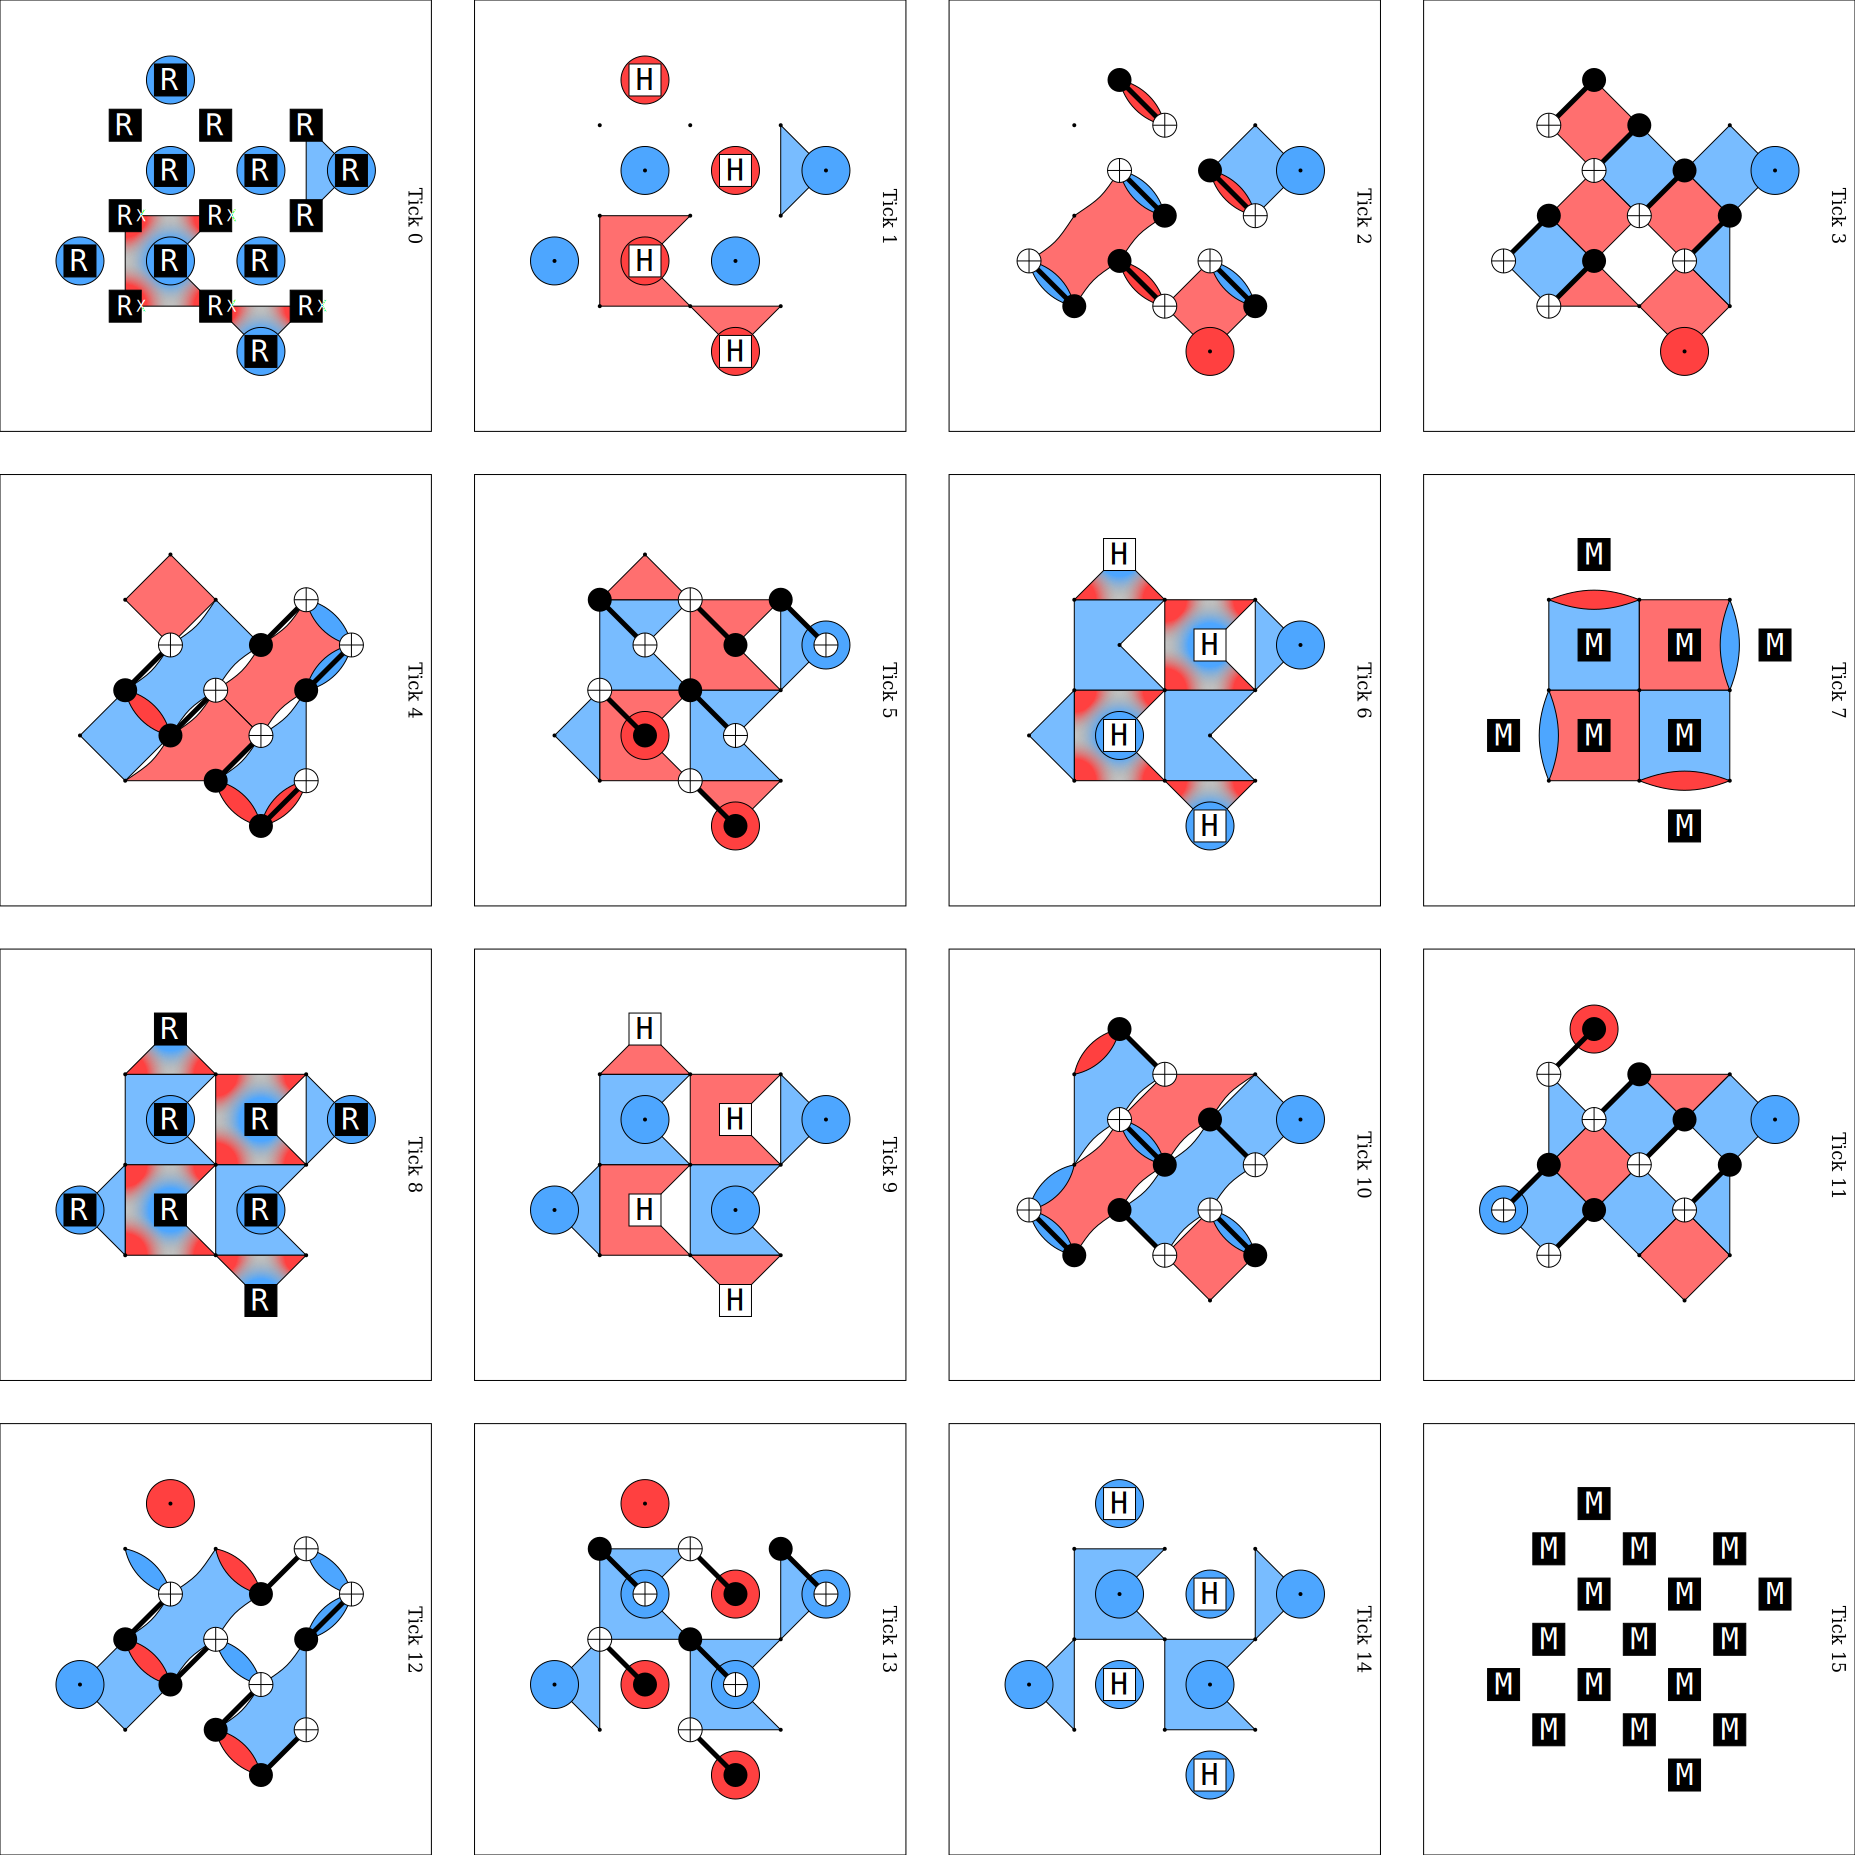

In [4]:
exp = StateInjectionExperiment(distance=3, rounds=2, injection_protocol='corner', inject_state='Z')
circ = exp.build()
circ.without_noise().diagram('detslice-with-ops-svg')

## 4. Validation against reference CSV (`injection_results.csv`)

Reproduces three LER variants for every configuration in the reference file:

| Column | Definition |
|--------|-----------|
| `post` | Post-select on all syndrome-round detectors → raw observable error rate among kept shots (no decoder) |
| `no_post` | Raw observable error rate on **all** shots (no PS, no decoder) |
| `qec` | PyMatching-decoded error rate on **all** shots (no PS, with decoder) |

**Noise model:** `NoiseConfig(p_2q=p2)` — only 2-qubit gate errors, all other rates = 0.  
**Protocol:** corner injection.  
**Stop condition:** 100 post-errors collected, or 2 M raw shots (whichever comes first).

**Post-selection:** all syndrome-extraction-round detectors (time coordinate < max), excluding final-readout detectors. Gives 11 detectors for d=3/rounds=2.

**CSV normalisation:** LER values in `injection_results.csv` are stored as `LER / rounds`; the comparison multiplies them by `rounds` before computing ratios.

**Expected results:**
- `post_rate` and `no_post`/`post` — ratio ≈ 1.0 ✓  
- `qec` ?.

In [12]:
import pandas as pd
import pymatching
from src.noise.config import NoiseConfig
from src.simulation.decoder_backend.post_select import (
    get_post_select_detector_indices,
    apply_post_selection,
)

# ── Load reference ────────────────────────────────────────────────────────────
ref_df = pd.read_csv('../notebooks/injection_results.csv')

# Unique (distance, p2, rounds, inject_state) combinations — same order as CSV
configs = (
    ref_df[['distance', 'p2', 'rounds', 'inject_state']]
    .drop_duplicates()
    .values.tolist()
)

BATCH      = 50_000
MAX_SHOTS  = 2_000_000
N_ERR_STOP = 100        # stop when this many post errors are collected

rows = []  # collected results

for distance, p2, rounds, inject_state in configs:
    distance, rounds = int(distance), int(rounds)

    # ── Build circuit ─────────────────────────────────────────────────────────
    exp = StateInjectionExperiment(
        distance=distance,
        rounds=rounds,
        injection_protocol='corner',
        inject_state=inject_state,
        noise_params=NoiseConfig(p_2q=p2),
    )
    circ    = exp.build()

    # ── Post-select indices come from the circuit's tagged detectors ──────────
    # StateInjectionExperiment tags all syndrome-round detectors with
    # "post-select"; get_post_select_detector_indices recurses into REPEAT
    # blocks to collect their absolute indices.
    ps_idx  = get_post_select_detector_indices(circ)

    sampler = circ.compile_detector_sampler()
    dem     = circ.detector_error_model()
    matcher = pymatching.Matching.from_detector_error_model(dem)

    # ── Batch sampling loop ───────────────────────────────────────────────────
    total_shots = kept = post_err = no_post_err = qec_err = 0

    while total_shots < MAX_SHOTS and post_err < N_ERR_STOP:
        det_b, obs_b = sampler.sample(shots=BATCH, separate_observables=True)
        total_shots += BATCH

        # no_post: raw observable on all shots
        no_post_err += int(obs_b[:, 0].sum())

        # qec: PyMatching on all shots
        preds = matcher.decode_batch(det_b)
        qec_err += int((preds.flatten() != obs_b[:, 0]).sum())

        # post: post-select then raw observable
        det_f, obs_f = apply_post_selection(det_b, obs_b, ps_idx)
        kept      += det_f.shape[0]
        post_err  += int(obs_f[:, 0].sum())

    # ── Compute LERs ─────────────────────────────────────────────────────────
    post_rate   = kept / total_shots
    ler_post    = post_err    / kept         if kept        > 0 else float('nan')
    ler_no_post = no_post_err / total_shots
    ler_qec     = qec_err     / total_shots

    rows.append(dict(
        distance=distance, p2=p2, rounds=rounds, inject_state=inject_state,
        total_shots=total_shots, kept=kept, ps_dets=len(ps_idx),
        post_rate=post_rate,
        ler_post=ler_post, ler_no_post=ler_no_post, ler_qec=ler_qec,
    ))

# ── Build results DataFrame ───────────────────────────────────────────────────
sim_df = pd.DataFrame(rows)

# ── Comparison table ──────────────────────────────────────────────────────────
# CSV stores LER/rounds — multiply reference values by rounds before comparing.
# Tolerances:
#   post_rate  → strict   [0.98, 1.02]  (validates post-selection logic)
#   no_post    → moderate [0.5,  2.0]   (should match after rounds correction)
#   post       → moderate [0.5,  2.0]   (should match after rounds correction)
RATE_TOL = (0.98, 1.02)
LER_TOLS = {'post': (0.5, 2.0), 'no_post': (0.5, 2.0), 'qec': (0.0, 1.5)}

print(f"\n{'d':>2} {'p2':>7} {'r':>2} {'st':>2} | "
      f"{'pr_ref':>8} {'pr_sim':>8} {'ok':>3} | "
      f"{'LER_type':>8} {'ref×r':>10} {'sim':>10} {'ratio':>7}")
print("-" * 88)

rate_ok_all = True
ler_ok_all  = True

for _, row in sim_df.iterrows():
    d   = int(row['distance'])
    p2  = row['p2']
    r   = int(row['rounds'])
    st  = row['inject_state']
    mask = (
        (ref_df['distance']     == d)  &
        (ref_df['p2']           == p2) &
        (ref_df['rounds']       == r)  &
        (ref_df['inject_state'] == st)
    )
    ref_rows = ref_df[mask]

    pr_ref = ref_rows['post_rate'].iloc[0]
    pr_sim = row['post_rate']
    pr_ratio = pr_sim / pr_ref if pr_ref > 0 else float('nan')
    pr_ok = RATE_TOL[0] <= pr_ratio <= RATE_TOL[1]
    if not pr_ok:
        rate_ok_all = False

    for ler_type, ler_sim in [
        ('post',    row['ler_post']),
        ('no_post', row['ler_no_post']),
        ('qec',     row['ler_qec']),
    ]:
        ref_val = ref_rows.loc[ref_rows['LER_type'] == ler_type, 'LER'].values
        if len(ref_val) == 0:
            continue
        ref_val_corrected = ref_val[0] * r   # CSV stores LER/rounds

        if ref_val_corrected > 0 and not np.isnan(ler_sim):
            ratio = ler_sim / ref_val_corrected
            lo, hi = LER_TOLS[ler_type]
            flag  = '' if lo <= ratio <= hi else '  ← WARN'
            if flag:
                ler_ok_all = False
        else:
            ratio, flag = float('nan'), ''

        print(
            f"{d:>2} {p2:>7.4f} {r:>2} {st:>2} | "
            f"{pr_ref:>8.4f} {pr_sim:>8.4f} {'✓' if pr_ok else '✗':>3} | "
            f"{ler_type:>8} {ref_val_corrected:>10.4e} {ler_sim:>10.4e} {ratio:>7.3f}{flag}"
        )
print(circ)
print()
if rate_ok_all:
    print("post_rate : ALL PASS — post-selection logic validated ✓")
else:
    print("post_rate : SOME FAIL — post-selection logic may have issues ✗")

if ler_ok_all:
    print("LER ratios: ALL within tolerance ✓")
else:
    print("LER ratios: some outside tolerance (see WARNs above) ✗")

Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Applying first round of syndrome extraction...
Applying rest

In [13]:

import stim


exp = StateInjectionExperiment(
    distance=3,
    rounds=2,
    injection_protocol='corner',
    inject_state='Z',
    noise_params=NoiseConfig(p_2q=1e-4),
)
circ = exp.build()
# circ2 = stim.Circuit('''
#     QUBIT_COORDS(2, 0) 0
#     QUBIT_COORDS(1, 1) 1
#     QUBIT_COORDS(3, 1) 2
#     QUBIT_COORDS(5, 1) 3
#     QUBIT_COORDS(2, 2) 4
#     QUBIT_COORDS(4, 2) 5
#     QUBIT_COORDS(6, 2) 6
#     QUBIT_COORDS(1, 3) 7
#     QUBIT_COORDS(3, 3) 8
#     QUBIT_COORDS(5, 3) 9
#     QUBIT_COORDS(0, 4) 10
#     QUBIT_COORDS(2, 4) 11
#     QUBIT_COORDS(4, 4) 12
#     QUBIT_COORDS(1, 5) 13
#     QUBIT_COORDS(3, 5) 14
#     QUBIT_COORDS(5, 5) 15
#     QUBIT_COORDS(4, 6) 16
#     RX 7 8 13 14 15
#     Z_ERROR(0) 7 8 13 14 15
#     R 2 3 9
#     X_ERROR(0) 2 3 9
#     R 1
#     X_ERROR(0) 1
#     TICK
#     DEPOLARIZE1(0) 1 2 3 7 8 9 13 14 15
#     H 0 5 11 16
#     DEPOLARIZE1(0) 0 5 11 16
#     TICK
#     CX 0 2 5 9 11 14 8 4 13 10 15 12
#     DEPOLARIZE2(0.001) 0 2 5 9 11 14 8 4 13 10 15 12
#     TICK
#     CX 0 1 5 8 11 13 2 4 7 10 9 12
#     DEPOLARIZE2(0.001) 0 1 5 8 11 13 2 4 7 10 9 12
#     TICK
#     CX 5 3 11 8 16 15 7 4 9 6 14 12
#     DEPOLARIZE2(0.001) 5 3 11 8 16 15 7 4 9 6 14 12
#     TICK
#     CX 5 2 11 7 16 14 1 4 3 6 8 12
#     DEPOLARIZE2(0.001) 5 2 11 7 16 14 1 4 3 6 8 12
#     TICK
#     H 0 5 11 16
#     DEPOLARIZE1(0) 0 5 11 16
#     TICK
#     X_ERROR(0) 0 4 5 6 10 11 12 16
#     MR 0 4 5 6 10 11 12 16
#     X_ERROR(0) 0 4 5 6 10 11 12 16
#     DETECTOR(4, 6, 0) rec[-1]
#     DETECTOR(2, 4, 0) rec[-3]
#     DETECTOR(6, 2, 0) rec[-5]
#     TICK
#     DEPOLARIZE1(0) 1 2 3 7 8 9 13 14 15
#     H 0 5 11 16
#     DEPOLARIZE1(0) 0 5 11 16
#     TICK
#     CX 0 2 5 9 11 14 8 4 13 10 15 12
#     DEPOLARIZE2(0.001) 0 2 5 9 11 14 8 4 13 10 15 12
#     TICK
#     CX 0 1 5 8 11 13 2 4 7 10 9 12
#     DEPOLARIZE2(0.001) 0 1 5 8 11 13 2 4 7 10 9 12
#     TICK
#     CX 5 3 11 8 16 15 7 4 9 6 14 12
#     DEPOLARIZE2(0.001) 5 3 11 8 16 15 7 4 9 6 14 12
#     TICK
#     CX 5 2 11 7 16 14 1 4 3 6 8 12
#     DEPOLARIZE2(0.001) 5 2 11 7 16 14 1 4 3 6 8 12
#     TICK
#     H 0 5 11 16
#     DEPOLARIZE1(0) 0 5 11 16
#     TICK
#     X_ERROR(0) 0 4 5 6 10 11 12 16
#     MR 0 4 5 6 10 11 12 16
#     X_ERROR(0) 0 4 5 6 10 11 12 16
#     SHIFT_COORDS(0, 0, 1)
#     DETECTOR(4, 6, 0) rec[-1] rec[-9]
#     DETECTOR(4, 4, 0) rec[-2] rec[-10]
#     DETECTOR(2, 4, 0) rec[-3] rec[-11]
#     DETECTOR(0, 4, 0) rec[-4] rec[-12]
#     DETECTOR(6, 2, 0) rec[-5] rec[-13]
#     DETECTOR(4, 2, 0) rec[-6] rec[-14]
#     DETECTOR(2, 2, 0) rec[-7] rec[-15]
#     DETECTOR(2, 0, 0) rec[-8] rec[-16]
#     M 1 2 3 7 8 9 13 14 15
#     OBSERVABLE_INCLUDE(0) rec[-9] rec[-8] rec[-7]
# ''')
# dem2 = circ2.detector_error_model()
# dem = circ.detector_error_model()
# print("dem1", dem)
# print("dem2", dem2)
print(circ)

Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
QUBIT_COORDS(2, 0) 0
QUBIT_COORDS(1, 1) 1
QUBIT_COORDS(3, 1) 2
QUBIT_COORDS(5, 1) 3
QUBIT_COORDS(2, 2) 4
QUBIT_COORDS(6, 2) 5
QUBIT_COORDS(4, 2) 6
QUBIT_COORDS(1, 3) 7
QUBIT_COORDS(3, 3) 8
QUBIT_COORDS(5, 3) 9
QUBIT_COORDS(0, 4) 10
QUBIT_COORDS(4, 4) 11
QUBIT_COORDS(2, 4) 12
QUBIT_COORDS(1, 5) 13
QUBIT_COORDS(3, 5) 14
QUBIT_COORDS(5, 5) 15
QUBIT_COORDS(4, 6) 16
RX 7 8 13 14 15
R 1 2 3 9 0 4 5 6 10 11 12 16
TICK[SE_start]
H 0 6 12 16
TICK
CX 0 2 6 9 12 14 8 4 13 10 15 11
DEPOLARIZE2(0.0001) 0 2 6 9 12 14 8 4 13 10 15 11
TICK
CX 0 1 6 8 12 13 2 4 7 10 9 11
DEPOLARIZE2(0.0001) 0 1 6 8 12 13 2 4 7 10 9 11
TICK
CX 6 3 12 8 16 15 7 4 9 5 14 11
DEPOLARIZE2(0.0001) 6 3 12 8 16 15 7 4 9 5 14 11
TICK
CX 6 2 12 7 16 14 1 4 3 5 8 11
DEPOLARIZE2(0.0001) 6 2 12 7 16 14 1 4 3 5 8 11
TICK
H 0 6 12 16
TICK
M 0 4 5 6 10 11 12 16
DETECTOR[post-select](6, 2, 0) rec[-6]
DETECTOR[post-select](2, 4, 0) rec[-2]
DETEC